Author: HC

version: 0.2

last modifs : 07/09/2025

# Library Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import glob
import re
from IPython.display import clear_output

# Def parameters

In [2]:
ZT0 = "7:00:00 AM"

dir_input = 'D:\Temp\Sleep_recordings'

annot_dict = {
    "6-16-2025" : "NS",
    "6-27-2025" : "SDW1",
    "7-4-2025" : "SDW2",
    "7-11-2025" : "SDW3",
    "7-19-2025" : "SDW4",
    "7-20-2025" : "Sleep-rebound",
    "7-29-2025" : "Sepsis",

}

if not os.path.exists(f'{dir_input}/output/'):
    output_dir = os.mkdir(f'{dir_input}/output/')


# Def function

In [3]:
def separate_days(dir_input, ZT0, annot_dict = annot_dict):
    list_files = glob.glob(dir_input + '/' + '*_whole-recording.csv')
    output_dir = f'{dir_input}/output'

    if len(list_files) == 0:
        print('No file matching expected format found, please double check files name ("ID_{mouseIDorwhatever}_whole-recording.csv") and input pathway.')

    for n, file in enumerate(list_files):
        sample = re.split("_", list_files[n])[-2]

        print(f"Start processing of {sample} recording")
        
        df = pd.read_csv(file, low_memory=False)
        df.drop(labels=0, axis=0,inplace=True) ## Remove units
        df = df.reset_index()
        if df.columns[-1] != 'Activity':
            df.drop(labels=df.columns[-1],axis=1,inplace=True)
        if df.columns[0] == 'index':
            df.drop(labels=df.columns[0],axis=1,inplace=True)
        
        unique_dates = df['Time Stamp'].apply(lambda x : x.split(' ')[0])
        unique_dates = unique_dates.unique().astype(str)
        unique_dates_noslash = np.char.replace(unique_dates, "/","-") ## For new filename

        list_pos_CT0 = {}
        for n, date in enumerate(unique_dates):
            print(n, date)
            nex = n+1
            if n==0:
                debut = 0
                temp_position = df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index[0] - 1
            elif n == len(unique_dates) - 1 :
                debut = df[df['Time Stamp']==f'{unique_dates[n]} {ZT0}'].index[0]
                temp_position = len(df)
            else:
                debut = df[df['Time Stamp']==f'{unique_dates[n]} {ZT0}'].index[0]
                temp_position = df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index[0] - 1

            list_pos_CT0[unique_dates[n]] = (debut,temp_position)

        list_pos_CT0
        clear_output()

        exp_df = pd.DataFrame(data = {"Date" : unique_dates_noslash,
                              "Expe": np.zeros(len(unique_dates))})
        
        if len(annot_dict) > 0:
            current_exp = ["Undefined"]
            # print(annot_dict)
            for n, date in enumerate(exp_df['Date'].unique()):
                # print(n, date)
                if date in annot_dict.keys():
                    current_exp = annot_dict[date]
                exp_df.loc[n,"Expe"] = current_exp


        pd.options.mode.copy_on_write = True
        for n, key in enumerate(list_pos_CT0.keys()):
            df_temp = df[list_pos_CT0[key][0]:list_pos_CT0[key][1]]
            df_temp.dropna(thresh= 2, axis=0, inplace= True)
            # print(len(df_temp))
            if len(df_temp) > 1:
                if len(annot_dict) > 0:
                    df_temp.to_csv(f'{dir_input}\output\{exp_df.loc[n,"Date"]}_{sample}-{exp_df.loc[n,"Expe"]}.csv',index=None)
                else:
                    df_temp.to_csv(f'{dir_input}\output\{exp_df.loc[n,"Date"]}_{sample}.csv',index=None)
        
    print(" ")
    print('Done')

# Run function

In [5]:
separate_days(dir_input = dir_input,
              ZT0 = ZT0,
              annot_dict = annot_dict
              )

 
Done


# Debugging only, please ignore.

In [ ]:
df = pd.read_csv(f'{dir_input}\ID_1267843_whole-recording.csv')

df.drop(labels=0, axis=0,inplace=True) ## Remove units
df = df.reset_index()
if df.columns[-1] != 'Activity':
    df.drop(labels=df.columns[-1],axis=1,inplace=True)
if df.columns[0] == 'index':
    df.drop(labels=df.columns[0],axis=1,inplace=True)

unique_dates = df['Time Stamp'].apply(lambda x : x.split(' ')[0])
unique_dates = unique_dates.unique().astype(str)
unique_dates_noslash = np.char.replace(unique_dates, "/","-") ## For new filename



In [ ]:
df

In [ ]:
list_pos_CT0 = {}
for n, date in enumerate(unique_dates):
    print(n, date)
    nex = n+1
    if n==0:
        debut = 0
        temp_position = df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index[0] - 1
    elif n == len(unique_dates) - 1 :
        debut = df[df['Time Stamp']==f'{unique_dates[n]} {ZT0}'].index[0]
        temp_position = len(df)
    else:
        debut = df[df['Time Stamp']==f'{unique_dates[n]} {ZT0}'].index[0]
        temp_position = df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index[0] - 1

    list_pos_CT0[unique_dates[n]] = (debut,temp_position)

list_pos_CT0



In [ ]:
df[df['Time Stamp']==f'{unique_dates[nex]} {ZT0}'].index

In [ ]:
annot_dict = {
    "6-16-2025" : "NS",
    "6-27-2025" : "SDW1",
    "7-4-2025" : "SDW2",
    "7-11-2025" : "SDW3"
}

In [ ]:
current_exp = ["Undefined"]
current_exp = annot_dict['06-16-2025']
current_exp

In [ ]:
annot_df = pd.DataFrame(data= {"Date" : annot_dict.keys(),
                               "Exp" : annot_dict.values()})
print(annot_df)
# unique_dates

In [ ]:
exp_df = pd.DataFrame(data = {"Date" : unique_dates,
                              "Expe": np.zeros(len(unique_dates))})
exp_df

In [ ]:
len(annot_dict)

In [ ]:
current_exp = []
for n, date in enumerate(exp_df['Date'].unique()):
    # print(n, date)
    if date in annot_dict.keys():
        current_exp = annot_dict[date]
    exp_df.loc[n,"Expe"] = current_exp

exp_df

In [ ]:
sample = "test"

In [ ]:
unique_dates_noslash2

In [ ]:
pd.options.mode.copy_on_write = True
for n, key in enumerate(list_pos_CT0.keys()):
    df_temp = df[list_pos_CT0[key][0]:list_pos_CT0[key][1]]
    df_temp.dropna(thresh= 2, axis=0, inplace= True)
    # print(len(df_temp))
    if len(df_temp) > 1:
        df_temp.to_csv(f'{dir_input}\output\{exp_df.loc[n,"Date"]}_{sample}-{exp_df.loc[n,"Expe"]}.csv',index=None)

In [ ]:
unique_dates_noslash

# Plots

## Separate data

In [37]:
df_NS = pd.read_excel(r'E:\R\Sleep\Output\2025-06-16_Normal-Sleep\1269984_2025-06-16_Normal-Sleep.xlsx', sheet_name = 'ZT-Mean')
df_SD = pd.read_excel(r'E:\R\Sleep\Output\2025-06-27_Sleep-Disruption_week1\1269984_2025-06-27_Sleep-Disruption_week1.xlsx', sheet_name = 'ZT-Mean')

In [38]:
df_NS['Total_Sleep_pct'] = df_NS['NREM_Percent'] + df_NS['REM_Percent']
df_SD['Total_Sleep_pct'] = df_SD['NREM_Percent'] + df_SD['REM_Percent']

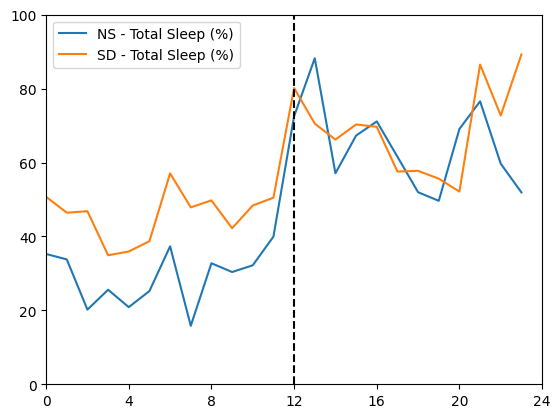

In [43]:
import matplotlib.pyplot as plt
plt.plot(df_NS['Wake_Percent'], label ='NS - Total Sleep (%)')
plt.plot(df_SD['Wake_Percent'], label ='SD - Total Sleep (%)')
plt.vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
plt.xlim(0,24)
plt.ylim(0,100)
plt.xticks([0,4,8,12,16,20,24])
plt.legend()

## Combined Data

In [8]:
df = pd.read_excel(r'D:\Xenium\Analysis\SD\Sleep-summary-no84.xlsx', sheet_name='forPython')

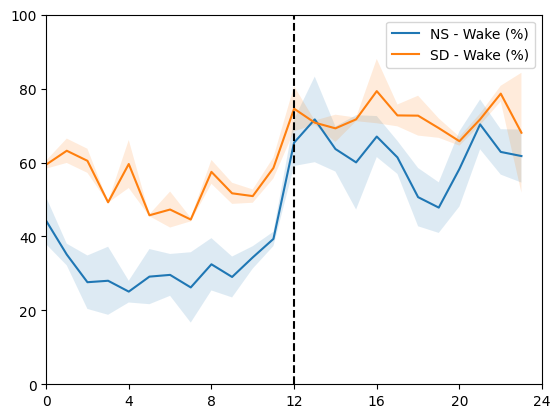

In [11]:
plt.plot(df['NS_W_A'], label ='NS - Wake (%)')
plt.plot(df['SD_W_A'], label ='SD - Wake (%)')

# plt.errorbar(x = df['ZT'], y = df['NS_W_A'], yerr=df['NS_W_SEM'], label ='NS - Wake (%)')
# plt.errorbar(x = df['ZT'], y = df['SD_W_A'], yerr=df['SD_W_SEM'], label ='SD - Wake (%)')
plt.vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
plt.fill_between(x= df['ZT'], y1 = df['NS_W_A'] - df['NS_W_SD'], y2 = df['NS_W_A'] + df['NS_W_SD'], alpha=.15)
plt.fill_between(x= df['ZT'], y1 = df['SD_W_A'] - df['SD_W_SD'], y2 = df['SD_W_A'] + df['SD_W_SD'], alpha=.15)
plt.xlim(0,24)
plt.ylim(0,100)
plt.xticks([0,4,8,12,16,20,24])
plt.legend()

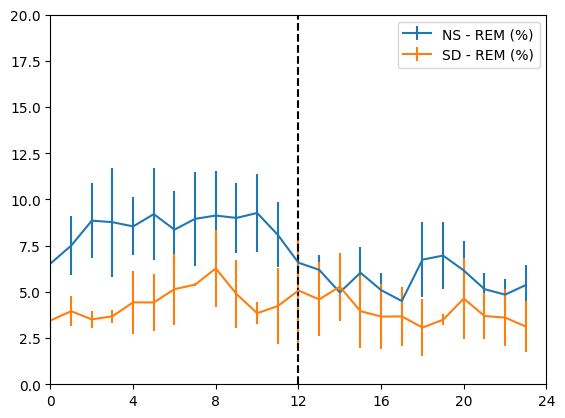

In [10]:
plt.errorbar(x = df['ZT'], y = df['NS_REM_A'], yerr=df['NS_REM_SEM'], label ='NS - REM (%)')
plt.errorbar(x = df['ZT'], y = df['SD_REM_A'], yerr=df['SD_REM_SEM'], label ='SD - REM (%)')
plt.vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
plt.xlim(0,24)
plt.ylim(0,20)
plt.xticks([0,4,8,12,16,20,24])
plt.legend()

In [142]:
import matplotlib.pyplot as plt
# import 
import matplotlib as mpl


# Ensure text remains editable in SVG

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects



# Optional: improve SVG precision

mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

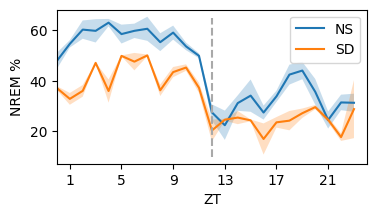

In [12]:
plt.figure(figsize=(4,2))
# plt.errorbar(x = df['ZT'], y = df['NS_NREM_A'], yerr=df['NS_NREM_SEM'], label ='NS - NREM (%)')
# plt.errorbar(x = df['ZT'], y = df['SD_NREM_A'], yerr=df['SD_NREM_SEM'], label ='SD - NREM (%)')
plt.plot(df['NS_NREM_A'], label ='NS')
plt.plot(df['SD_NREM_A'],label ='SD')
plt.fill_between(x= df['ZT'], y1 = df['NS_NREM_A'] - df['NS_W_SEM'], y2 = df['NS_NREM_A'] + df['NS_W_SEM'], alpha=.25)
plt.fill_between(x= df['ZT'], y1 = df['SD_NREM_A'] - df['SD_W_SEM'], y2 = df['SD_NREM_A'] + df['SD_W_SEM'], alpha=.25)
plt.vlines(x=12, ymin=10, ymax=65, linestyles='dashed', color = 'darkgrey')
plt.xlabel('ZT')
plt.ylabel("NREM %")
plt.xlim(0,24)
# plt.ylim(0,100)
plt.xticks([1,5,9,13,17,21])
plt.legend(loc = 'upper right')
plt.savefig('Gallery/sleep_NS-vs-SD.svg', format = 'svg', transparent = True)


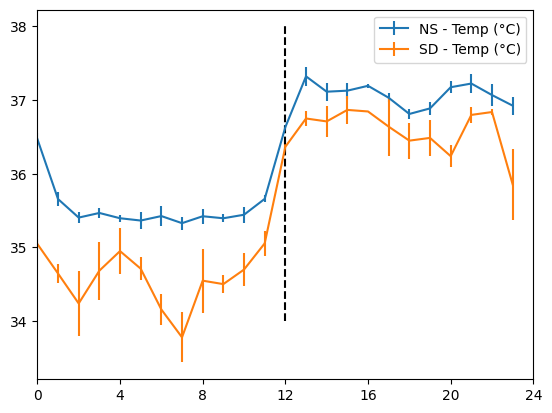

In [118]:
plt.errorbar(x = df['ZT'], y = df['NS_Temp_A'], yerr=df['NS_Temp_SEM'], label ='NS - Temp (°C)')
plt.errorbar(x = df['ZT'], y = df['SD_Temp_A'], yerr=df['SD_Temp_SEM'], label ='SD - Temp (°C)')
plt.vlines(x=12, ymin=34, ymax=38, linestyles='dashed', color = 'black')
plt.xlim(0,24)
# plt.ylim(0,20)
plt.xticks([0,4,8,12,16,20,24])
plt.legend()

Text(0.5, 0, 'ZT')

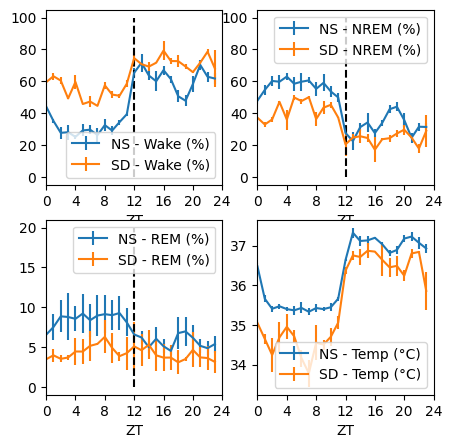

In [13]:
fig, ax = plt.subplots(2,2, figsize=(5,5))
ax = ax.flatten()

ax[0].errorbar(x = df['ZT'], y = df['NS_W_A'], yerr=df['NS_W_SEM'], label ='NS - Wake (%)')
ax[0].errorbar(x = df['ZT'], y = df['SD_W_A'], yerr=df['SD_W_SEM'], label ='SD - Wake (%)')
ax[0].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[0].set_xlim(0,24)
ax[0].set_xticks([0,4,8,12,16,20,24])
ax[0].legend(loc = 'lower right')

ax[1].errorbar(x = df['ZT'], y = df['NS_NREM_A'], yerr=df['NS_NREM_SEM'], label ='NS - NREM (%)')
ax[1].errorbar(x = df['ZT'], y = df['SD_NREM_A'], yerr=df['SD_NREM_SEM'], label ='SD - NREM (%)')
ax[1].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[1].set_xlim(0,24)
ax[1].set_xticks([0,4,8,12,16,20,24])
ax[1].legend(loc = 'upper right')

ax[2].errorbar(x = df['ZT'], y = df['NS_REM_A'], yerr=df['NS_REM_SEM'], label ='NS - REM (%)')
ax[2].errorbar(x = df['ZT'], y = df['SD_REM_A'], yerr=df['SD_REM_SEM'], label ='SD - REM (%)')
ax[2].vlines(x=12, ymin=0, ymax=20, linestyles='dashed', color = 'black')
ax[2].set_xlim(0,24)
ax[2].set_xticks([0,4,8,12,16,20,24])
ax[2].legend(loc = 'upper right')

ax[3].errorbar(x = df['ZT'], y = df['NS_Temp_A'], yerr=df['NS_Temp_SEM'], label ='NS - Temp (°C)')
ax[3].errorbar(x = df['ZT'], y = df['SD_Temp_A'], yerr=df['SD_Temp_SEM'], label ='SD - Temp (°C)')
ax[3].set_xlim(0,24)
ax[3].set_xticks([0,4,8,12,16,20,24])
ax[3].legend(loc = 'lower right')

ax[3].set_xlabel('ZT')
ax[2].set_xlabel('ZT')
ax[1].set_xlabel('ZT')
ax[0].set_xlabel('ZT')

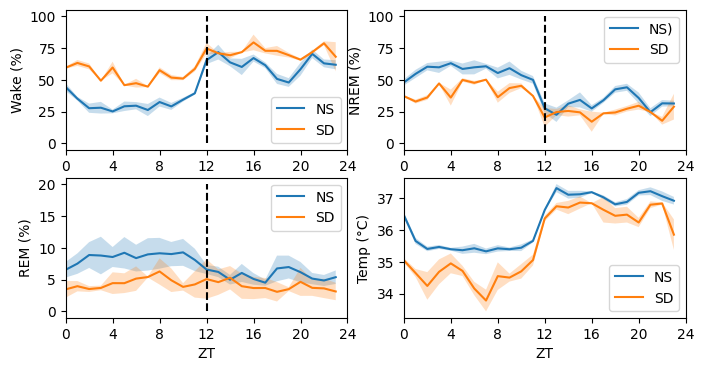

In [22]:
fig, ax = plt.subplots(2,2, figsize=(8,4))
ax = ax.flatten()

ax[0].plot(df['NS_W_A'], label ='NS')
ax[0].plot(df['SD_W_A'],  label ='SD')
ax[0].set_ylabel('Wake (%)')
ax[0].fill_between(x= df['ZT'], y1 = df['NS_W_A'] - df['NS_W_SEM'], y2 = df['NS_W_A'] + df['NS_W_SEM'], alpha=.25)
ax[0].fill_between(x= df['ZT'], y1 = df['SD_W_A'] - df['SD_W_SEM'], y2 = df['SD_W_A'] + df['SD_W_SEM'], alpha=.25)
ax[0].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[0].set_xlim(0,24)
ax[0].set_xticks([0,4,8,12,16,20,24])
ax[0].legend(loc = 'lower right')

ax[1].plot(df['NS_NREM_A'], label ='NS)')
ax[1].plot(df['SD_NREM_A'], label ='SD')
ax[1].set_ylabel('NREM (%)')
ax[1].fill_between(x= df['ZT'], y1 = df['NS_NREM_A'] - df['NS_NREM_SEM'], y2 = df['NS_NREM_A'] + df['NS_NREM_SEM'], alpha=.25)
ax[1].fill_between(x= df['ZT'], y1 = df['SD_NREM_A'] - df['SD_NREM_SEM'], y2 = df['SD_NREM_A'] + df['SD_NREM_SEM'], alpha=.25)
ax[1].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[1].set_xlim(0,24)
ax[1].set_xticks([0,4,8,12,16,20,24])
ax[1].legend(loc = 'upper right')

ax[2].plot(df['NS_REM_A'], label ='NS')
ax[2].plot(df['SD_REM_A'], label ='SD')
ax[2].set_ylabel('REM (%)')
ax[2].fill_between(x= df['ZT'], y1 = df['NS_REM_A'] - df['NS_REM_SEM'], y2 = df['NS_REM_A'] + df['NS_REM_SEM'], alpha=.25)
ax[2].fill_between(x= df['ZT'], y1 = df['SD_REM_A'] - df['SD_REM_SEM'], y2 = df['SD_REM_A'] + df['SD_REM_SEM'], alpha=.25)
ax[2].vlines(x=12, ymin=0, ymax=20, linestyles='dashed', color = 'black')
ax[2].set_xlim(0,24)
ax[2].set_xticks([0,4,8,12,16,20,24])
ax[2].legend(loc = 'upper right')

ax[3].plot(df['NS_Temp_A'], label ='NS')
ax[3].plot(df['SD_Temp_A'],  label ='SD')
ax[3].set_ylabel('Temp (°C)')
ax[3].fill_between(x= df['ZT'], y1 = df['NS_Temp_A'] - df['NS_Temp_SEM'], y2 = df['NS_Temp_A'] + df['NS_Temp_SEM'], alpha=.25)
ax[3].fill_between(x= df['ZT'], y1 = df['SD_Temp_A'] - df['SD_Temp_SEM'], y2 = df['SD_Temp_A'] + df['SD_Temp_SEM'], alpha=.25)
ax[3].set_xlim(0,24)
ax[3].set_xticks([0,4,8,12,16,20,24])
ax[3].legend(loc = 'lower right')

ax[3].set_xlabel('ZT')
ax[2].set_xlabel('ZT')
# ax[1].set_xlabel('ZT')
# ax[0].set_xlabel('ZT')

plt.savefig('Gallery/all_param_sleep.svg', format="svg",transparent = True)

KeyError: 'NS_Temp_SD'

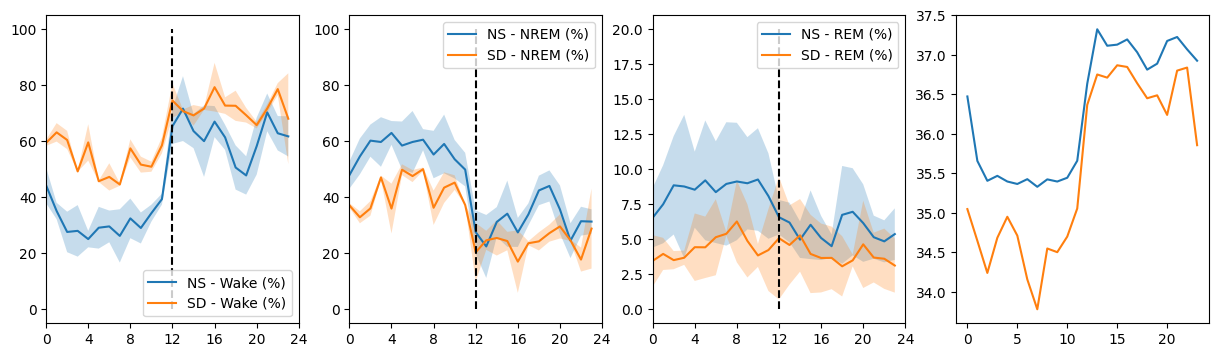

In [147]:
fig, ax = plt.subplots(1,4, figsize=(15,4))
ax = ax.flatten()

ax[0].plot(df['NS_W_A'], label ='NS - Wake (%)')
ax[0].plot(df['SD_W_A'],  label ='SD - Wake (%)')
ax[0].fill_between(x= df['ZT'], y1 = df['NS_W_A'] - df['NS_W_SD'], y2 = df['NS_W_A'] + df['NS_W_SD'], alpha=.25)
ax[0].fill_between(x= df['ZT'], y1 = df['SD_W_A'] - df['SD_W_SD'], y2 = df['SD_W_A'] + df['SD_W_SD'], alpha=.25)
ax[0].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[0].set_xlim(0,24)
ax[0].set_xticks([0,4,8,12,16,20,24])
ax[0].legend(loc = 'lower right')

ax[1].plot(df['NS_NREM_A'], label ='NS - NREM (%)')
ax[1].plot(df['SD_NREM_A'], label ='SD - NREM (%)')
ax[1].fill_between(x= df['ZT'], y1 = df['NS_NREM_A'] - df['NS_NREM_SD'], y2 = df['NS_NREM_A'] + df['NS_NREM_SD'], alpha=.25)
ax[1].fill_between(x= df['ZT'], y1 = df['SD_NREM_A'] - df['SD_NREM_SD'], y2 = df['SD_NREM_A'] + df['SD_NREM_SD'], alpha=.25)
ax[1].vlines(x=12, ymin=0, ymax=100, linestyles='dashed', color = 'black')
ax[1].set_xlim(0,24)
ax[1].set_xticks([0,4,8,12,16,20,24])
ax[1].legend(loc = 'upper right')

ax[2].plot(df['NS_REM_A'], label ='NS - REM (%)')
ax[2].plot(df['SD_REM_A'], label ='SD - REM (%)')
ax[2].fill_between(x= df['ZT'], y1 = df['NS_REM_A'] - df['NS_REM_SD'], y2 = df['NS_REM_A'] + df['NS_REM_SD'], alpha=.25)
ax[2].fill_between(x= df['ZT'], y1 = df['SD_REM_A'] - df['SD_REM_SD'], y2 = df['SD_REM_A'] + df['SD_REM_SD'], alpha=.25)
ax[2].vlines(x=12, ymin=0, ymax=20, linestyles='dashed', color = 'black')
ax[2].set_xlim(0,24)
ax[2].set_xticks([0,4,8,12,16,20,24])
ax[2].legend(loc = 'upper right')

ax[3].plot(df['NS_Temp_A'], label ='NS - Temp (°C)')
ax[3].plot(df['SD_Temp_A'],  label ='SD - Temp (°C)')
ax[3].fill_between(x= df['ZT'], y1 = df['NS_Temp_A'] - df['NS_Temp_SD'], y2 = df['NS_Temp_A'] + df['NS_Temp_SD'], alpha=.25)
ax[3].fill_between(x= df['ZT'], y1 = df['SD_Temp_A'] - df['SD_Temp_SD'], y2 = df['SD_Temp_A'] + df['SD_Temp_SD'], alpha=.25)
ax[3].set_xlim(0,24)
ax[3].set_xticks([0,4,8,12,16,20,24])
ax[3].legend(loc = 'lower right')

ax[3].set_xlabel('ZT')
ax[2].set_xlabel('ZT')
ax[1].set_xlabel('ZT')
ax[0].set_xlabel('ZT')

# Sleep transition

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects
mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

In [ ]:
df = pd.read_excel(r'E:\R\Sleep\output\2025-06-16_Normal-Sleep\1267843_2025-06-16_Normal-Sleep.xlsx', sheet_name='Sleep-transition')
df1 = pd.read_excel(r'E:\R\Sleep\output\2025-06-27_Sleep-Disruption_week1\1267843_2025-06-27_Sleep-Disruption_week1.xlsx', sheet_name='Sleep-transition')
df2 = pd.read_excel(r'E:\R\Sleep\output\2025-07-04_Sleep-Disruption_week2\1267843_2025-07-04_Sleep-Disruption_week2.xlsx', sheet_name='Sleep-transition')
df3= pd.read_excel(r'E:\R\Sleep\output\2025-07-11_Sleep-Disruption_week3\1267843_2025-07-11_Sleep-Disruption_week3.xlsx', sheet_name='Sleep-transition')


In [125]:
df.index = df.States_name
df.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)
df1.index = df1.States_name
df1.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)
df2.index = df2.States_name
df2.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)
df3.index = df3.States_name
df3.drop(['States_name', "W", "P", "c1", "c2", "c3", "c4", "c5", "c6"],axis = 1, inplace=True)

In [126]:
df.columns = df.index
df2.columns = df2.index
df1.columns = df1.index
df3.columns = df3.index

In [20]:
NS_df['average_df']

,ZT,Mean_W,Mean_P,Mean_c1,Mean_c2,Mean_c3,Mean_c4,Mean_c5,Mean_c6,Mean_W_percent,Mean_P_percent,Mean_c1_percent,Mean_c2_percent,Mean_c3_percent,Mean_c4_percent,Mean_c5_percent,Mean_c6_percent
0,W,67906.25,2051.00,437.50,678.25,410.25,959.00,843.75,769.75,90.445716,17.551866,5.770162,7.181453,5.316334,6.852984,7.139183,7.280293
1,P,2177.50,7309.25,541.00,938.75,447.50,1387.50,929.00,633.25,3.266560,37.683897,6.887453,9.737758,5.715717,10.254177,7.772930,6.179422
2,c1,430.00,638.00,3735.50,1057.50,1134.75,1264.75,568.00,392.25,0.714753,5.617177,33.083789,10.776762,13.089442,8.797044,4.409354,3.495125
3,c2,659.50,974.25,1071.00,3684.50,1010.50,1497.25,1219.00,777.50,1.040673,8.648681,13.016676,26.322717,11.942592,10.384738,9.718601,7.030757
4,c3,342.25,482.00,1244.75,986.75,3534.00,1045.00,942.25,710.00,0.558058,4.567686,15.027507,10.202797,31.663923,7.219683,7.487598,6.378525
5,c4,975.50,1388.25,1101.25,1482.00,980.25,6008.00,1982.00,1724.50,1.557383,11.771067,13.374839,15.002512,11.382825,32.350863,16.067110,15.926528
6,c5,814.00,917.00,655.00,1262.50,1035.25,1859.00,5281.75,2003.00,1.263768,8.416773,7.732047,12.786882,12.126849,12.898710,30.801428,18.395571
7,c6,743.75,605.00,435.75,804.25,735.50,1622.25,2062.75,5219.50,1.153090,5.742852,5.107527,7.989119,8.762317,11.241800,16.603797,35.313780


In [36]:
NsForHM = SDW3_df['average_df']
NsForHM.drop(['ZT', "Mean_W", "Mean_P", "Mean_c1", "Mean_c2", "Mean_c3", "Mean_c4", "Mean_c5", "Mean_c6"],axis = 1, inplace=True)

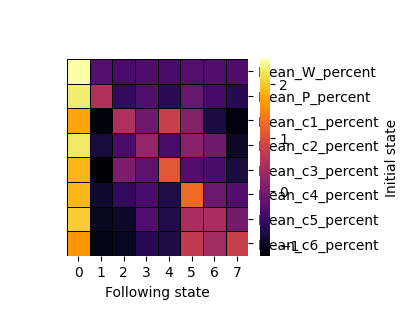

In [ ]:
sns.clustermap(NsForHM.T, cmap = 'inferno', z_score=0, linecolor = 'black',linewidths = .5,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None, figsize=(4,3)
                )
plt.xlabel('Following state')
plt.ylabel('Initial state')
plt.yticks(rotation = 0)
# plt.savefig(f'Gallery/{today}/heatmap_transitions_NS.svg', format = "svg", dpi= 300, transparent = True)

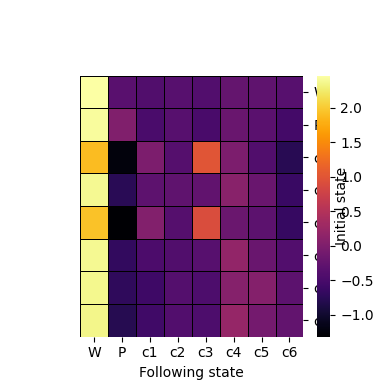

In [128]:
sns.clustermap(df1.T, cmap = 'inferno', z_score=0, linecolor = 'black',linewidths = .5,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None, figsize=(4,4)
                )
plt.xlabel('Following state')
plt.ylabel('Initial state')
plt.yticks(rotation = 0)
plt.savefig('Gallery/heatmap_transitions_SDW1.svg', format = "svg", dpi= 300, transparent = True)

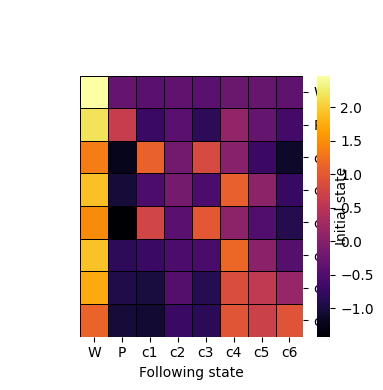

In [129]:
sns.clustermap(df2.T, cmap = 'inferno', z_score=0, linecolor = 'black',linewidths = .5,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None, figsize=(4,4)
                )
plt.xlabel('Following state')
plt.ylabel('Initial state')
plt.yticks(rotation = 0)
plt.savefig('Gallery/heatmap_transitions_SDW2.svg', format = "svg", dpi= 300, transparent = True)

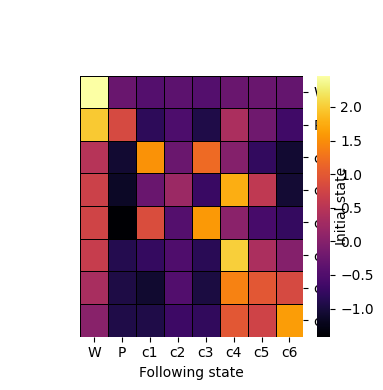

In [130]:
sns.clustermap(df3.T, cmap = 'inferno', z_score=0, linecolor = 'black',linewidths = .5,
                col_cluster=False,row_cluster=False, cbar = True, cbar_pos=None, figsize=(4,4)
                )
plt.xlabel('Following state')
plt.ylabel('Initial state')
plt.yticks(rotation = 0)
plt.savefig('Gallery/heatmap_transitions_SDW3.svg', format = "svg", dpi= 300, transparent = True)

# Automatic average

In [2]:
import pandas as pd
import os
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
mpl.rcParams['svg.fonttype'] = 'none'  # 'none' = keep text as text objects
mpl.rcParams['svg.hashsalt'] = ''  # consistent hashes for reproducibility

print(f"pandas version: {pd.__version__}")

pandas version: 2.0.1


In [3]:
dict_exp = {
    "NS" : "2025-06-16_Normal-Sleep",
    "SDW1" : "2025-06-27_Sleep-disruption_week1",
    "SDW2" : "2025-07-04_Sleep-disruption_week2",
    "SDW3" : "2025-07-11_Sleep-disruption_week3",
    # "SR" : "7-21-2025",
}

In [10]:
exp = "SDW3"
sheet_to_open = "ZT-Mean"

dir_input = r'E:\R\Sleep\output'
exp_folder_name = dict_exp[exp]
directory_expe = f'{dir_input}\{exp_folder_name}'

list_of_files = os.listdir(directory_expe)
list_of_files = [files for files in list_of_files if files[0]!="~"]
list_of_files

['1238359_2025-07-11_Sleep-Disruption_week3.xlsx',
 '1267843_2025-07-11_Sleep-Disruption_week3.xlsx',
 '1269984_2025-07-11_Sleep-Disruption_week3.xlsx']

In [11]:
dfs = []

for file in list_of_files:
    ID_mouse = file.split("_")[0]
    print(ID_mouse)
    df = pd.read_excel(f'{directory_expe}\{file}', sheet_name= sheet_to_open)
    ZT_list = df.iloc[:,0].astype(str)
    # df.iloc[:,0] = pd.Categorical(df.iloc[:,0])
    # df['subject'] = ID_mouse
    dfs.append(df)

ddf = dfs[0]
for n in range(1, len(dfs)):
    ddf = pd.concat([ddf,dfs[n]])

ddf

1238359
1267843
1269984


,ZT,Wake,NREM,REM,Total_Sleep,N_Wake,N_NREM,N_REM,Wake_Percent,NREM_Percent,...,Cluster3,Cluster4,Cluster5,Cluster6,Cluster1_Percent,Cluster2_Percent,Cluster3_Percent,Cluster4_Percent,Cluster5_Percent,Cluster6_Percent
0,0,859.666667,375.000000,13.333333,388.333333,3,3,3,68.883547,30.048077,...,52.000000,96.333333,82.666667,42.666667,9.866667,17.155556,13.866667,25.688889,22.044444,11.377778
1,1,870.666667,346.000000,19.000000,365.000000,3,3,3,70.461289,28.001079,...,58.000000,77.333333,62.333333,42.333333,9.441233,21.194605,16.763006,22.350674,18.015414,12.235067
2,2,793.000000,408.333333,14.666667,423.000000,3,3,3,65.213816,33.580044,...,28.333333,135.000000,85.333333,64.666667,8.734694,14.530612,6.938776,33.061224,20.897959,15.836735
3,3,737.000000,372.000000,19.333333,391.333333,3,3,3,65.317578,32.968981,...,29.000000,129.666667,67.000000,67.333333,9.050179,12.186380,7.795699,34.856631,18.010753,18.100358
4,4,1106.500000,466.500000,15.000000,481.500000,2,2,2,69.678841,29.376574,...,63.500000,164.000000,77.500000,71.500000,9.539121,9.753483,13.612004,35.155413,16.613076,15.326902
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,19,659.000000,814.500000,146.000000,960.500000,2,2,2,40.691571,50.293300,...,141.500000,147.000000,180.500000,119.500000,9.453653,18.293432,17.372621,18.047882,22.160835,14.671578
20,20,1053.500000,503.000000,100.500000,603.500000,2,2,2,63.578757,30.356065,...,73.000000,79.500000,117.500000,50.000000,8.648111,27.733598,14.512922,15.805169,23.359841,9.940358
21,21,1297.000000,254.500000,57.000000,311.500000,2,2,2,80.634131,15.822195,...,38.500000,34.500000,66.000000,37.500000,8.447937,22.200393,15.127701,13.555992,25.933202,14.734774
22,22,1310.500000,288.500000,41.000000,329.500000,2,2,2,79.908537,17.591463,...,68.000000,38.500000,68.000000,58.500000,6.239168,12.998267,23.570191,13.344887,23.570191,20.277296


In [32]:
average_df = pd.DataFrame(data = {"ZT":ZT_list})
std_df = pd.DataFrame(data = {"ZT":ZT_list})
sem_df = pd.DataFrame(data = {"ZT":ZT_list})

list_colums = list(ddf.columns)
list_colums.remove(ddf.columns[0])

for col in list_colums:
    average_df[f'Mean_{col}'] = ddf.groupby(ddf.index)[col].mean()
    std_df[f'Std_{col}'] = ddf.groupby(ddf.index)[col].std()
    sem_df[f'SEM_{col}'] = ddf.groupby(ddf.index)[col].std() / math.sqrt(len(ddf.groupby(ddf.index)))

combined = [average_df, std_df,sem_df]
list_of_files = ['average_df', 'std_df', 'sem_df']

writer = pd.ExcelWriter(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\{exp}_{sheet_to_open}_summ.xlsx', engine='xlsxwriter')
for j in range(0,len(combined)):
    combined[j].to_excel(writer, sheet_name=list_of_files[j], index=False)
writer.close()

In [26]:
average_df

,ZT,Mean_W,Mean_P,Mean_c1,Mean_c2,Mean_c3,Mean_c4,Mean_c5,Mean_c6,Mean_W_percent,Mean_P_percent,Mean_c1_percent,Mean_c2_percent,Mean_c3_percent,Mean_c4_percent,Mean_c5_percent,Mean_c6_percent
0,W,42525.333333,1639.333333,713.666667,1424.666667,896.000000,2165.333333,1893.000000,1253.333333,80.881449,51.381617,28.683522,37.122641,32.626974,37.660301,40.812307,38.012117
1,P,1695.333333,640.666667,121.666667,211.000000,59.000000,294.333333,147.666667,97.333333,3.195873,16.753157,4.515190,5.073635,1.986519,4.674496,2.880829,2.567162
2,c1,589.000000,129.333333,381.666667,353.000000,330.000000,439.666667,251.333333,162.333333,1.139648,4.365415,13.878394,8.571434,10.744226,7.048977,4.968229,4.554958
3,c2,1379.000000,232.333333,342.000000,548.000000,331.333333,494.666667,436.666667,243.666667,2.663441,7.785595,12.594551,13.308374,10.750993,7.952008,8.675274,6.726326
4,c3,691.000000,67.666667,389.333333,355.000000,569.666667,368.666667,303.666667,222.333333,1.323357,2.235554,14.752917,8.829486,18.489195,6.101680,6.041875,6.193828
5,c4,2277.000000,296.666667,357.000000,462.666667,290.000000,1125.333333,631.666667,565.000000,4.351454,9.125002,13.023834,11.372041,9.567332,18.237026,12.790454,15.819769
6,c5,1955.666667,165.333333,203.666667,443.000000,295.333333,604.666667,719.333333,481.666667,3.732676,5.174324,7.713550,10.700105,9.513461,9.965436,14.349015,13.003905
7,c6,1393.666667,96.666667,128.333333,211.333333,197.000000,513.666667,484.000000,509.000000,2.712101,3.179337,4.838043,5.022284,6.321298,8.360077,9.482017,13.121934


## Import dfs

In [35]:
sheet_to_open = "Sleep-transition-all"

NS_df = pd.read_excel(fr'data\Sleep-distruption-exp\NS_{sheet_to_open}_summ.xlsx', sheet_name=None)
SDW1_df = pd.read_excel(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\SDW1_{sheet_to_open}_summ.xlsx', sheet_name=None)
# SDW2_df = pd.read_excel(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\SDW2_{sheet_to_open}_summ.xlsx', sheet_name=None)
SDW3_df = pd.read_excel(fr'E:\R\SleepAnalysis\data\Sleep-distruption-exp\SDW3_{sheet_to_open}_summ.xlsx', sheet_name=None)

In [15]:
NS_df['average_df'].columns

Index(['ZT', 'Mean_W', 'Mean_P', 'Mean_c1', 'Mean_c2', 'Mean_c3', 'Mean_c4',
       'Mean_c5', 'Mean_c6', 'Mean_W_percent', 'Mean_P_percent',
       'Mean_c1_percent', 'Mean_c2_percent', 'Mean_c3_percent',
       'Mean_c4_percent', 'Mean_c5_percent', 'Mean_c6_percent'],
      dtype='object')

## Plots

KeyError: 'Mean_NREM_Percent'

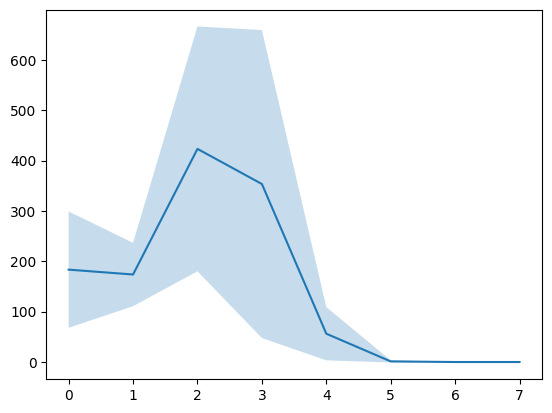

In [48]:
plt.plot(average_df['Mean_Light_phase_min'], label = "Wake")
plt.fill_between(x=std_df.index,
                 y1=average_df['Mean_Light_phase_min']-std_df['Std_Light_phase_min'],
                 y2 =average_df['Mean_Light_phase_min']+std_df['Std_Light_phase_min'],
                 alpha=0.25)
plt.plot(average_df['Mean_NREM_Percent'], label = "NREM")
plt.fill_between(x=std_df.index,
                 y1=average_df['Mean_NREM_Percent']-std_df['Std_NREM_Percent'],
                 y2 =average_df['Mean_NREM_Percent']+std_df['Std_NREM_Percent'],
                 alpha=0.25)
plt.plot(average_df['Mean_REM_Percent'], label = "REM")
plt.fill_between(x=std_df.index,
                 y1=average_df['Mean_REM_Percent']-std_df['Std_REM_Percent'],
                 y2 =average_df['Mean_REM_Percent']+std_df['Std_REM_Percent'],
                 alpha=0.25)
plt.xlabel('ZT')
plt.ylabel('Percentage')
plt.xticks([0,4,8,12,16,20,24])
plt.vlines(x=12,ymin=0,ymax = 80, linestyles='dashed', color = "grey")
plt.xlim(0,24)
plt.ylim(0)
plt.legend()
plt.title(f'{exp}')
# plt.savefig(f'Gallery/{exp}_all.svg', format = 'svg',transparent =True)

### Three Graphs

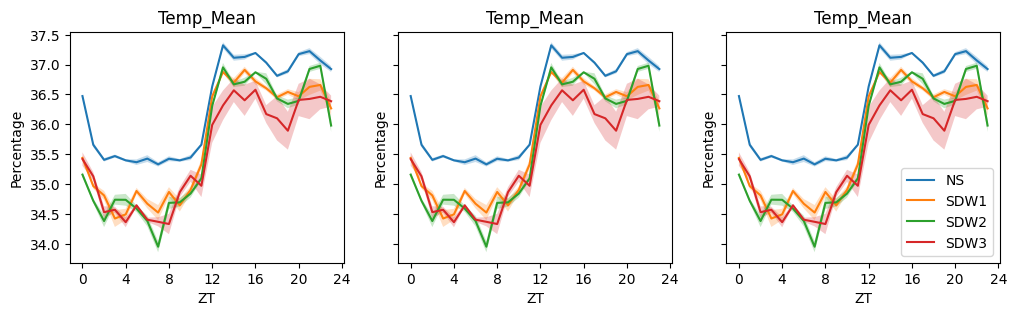

In [ ]:
vari_plt = ['Temp_Mean', 'Temp_Mean', 'Temp_Mean']

fig, ax = plt.subplots(1,3, figsize=(12,3), sharex=True, sharey=True)

for n in range(len(vari_plt)):
    ax[n].plot(NS_df['average_df'][f'Mean_{vari_plt[n]}'], label = "NS")
    ax[n].plot(SDW1_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW1")
    ax[n].plot(SDW2_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW2")
    ax[n].plot(SDW3_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW3")
    ax[n].set_xlabel('ZT')
    ax[n].set_ylabel('Percentage')
    ax[n].set_xticks([0,4,8,12,16,20,24])
    # ax[n].vlines(x=12,ymin=0,ymax = 80, linestyles='dashed', color = "grey")
    ax[n].set_title(vari_plt[n])

    ax[n].fill_between(x = NS_df['average_df']['ZT'],
                    y1 = NS_df['average_df'][f'Mean_{vari_plt[n]}']-NS_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = NS_df['average_df'][f'Mean_{vari_plt[n]}']+NS_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW1_df['average_df']['ZT'],
                    y1 = SDW1_df['average_df'][f'Mean_{vari_plt[n]}']-SDW1_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW1_df['average_df'][f'Mean_{vari_plt[n]}']+SDW1_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW2_df['average_df']['ZT'],
                    y1 = SDW2_df['average_df'][f'Mean_{vari_plt[n]}']-SDW2_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW2_df['average_df'][f'Mean_{vari_plt[n]}']+SDW2_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW3_df['average_df']['ZT'],
                    y1 = SDW3_df['average_df'][f'Mean_{vari_plt[n]}']-SDW3_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW3_df['average_df'][f'Mean_{vari_plt[n]}']+SDW3_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.savefig(fr'Gallery\\all-recording_{vari_plt}.svg', format = 'svg',transparent = True)

### Six graphs

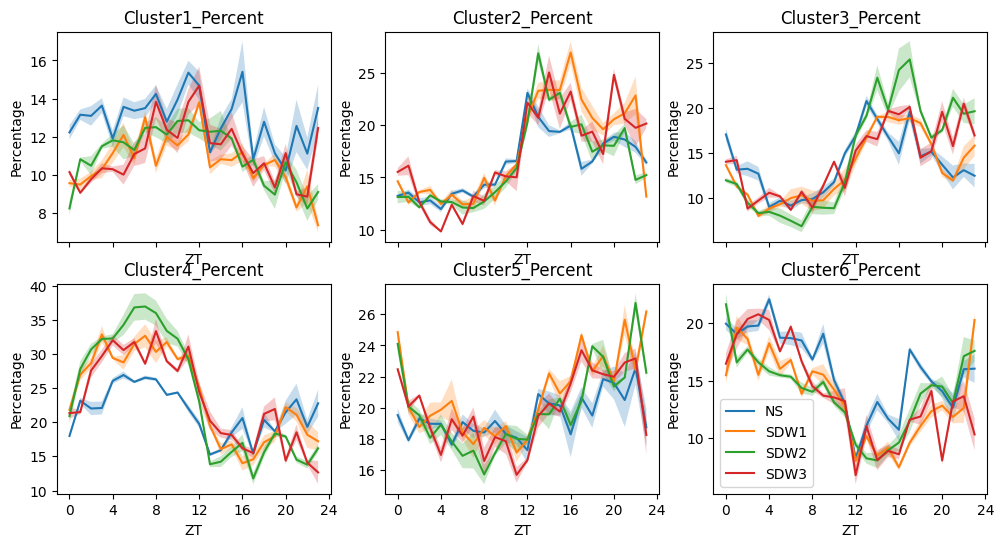

In [24]:
# vari_plt = ['Wake_Percent', 'NREM_Percent', 'REM_Percent']
vari_plt = ['Cluster1_Percent',
       'Cluster2_Percent', 'Cluster3_Percent',
       'Cluster4_Percent', 'Cluster5_Percent',
       'Cluster6_Percent']

fig, ax = plt.subplots(2,3, figsize=(12,6), sharex=True, sharey=False)
ax = ax.flatten()

for n in range(len(vari_plt)):
    ax[n].plot(NS_df['average_df'][f'Mean_{vari_plt[n]}'], label = "NS")
    ax[n].plot(SDW1_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW1")
    ax[n].plot(SDW2_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW2")
    ax[n].plot(SDW3_df['average_df'][f'Mean_{vari_plt[n]}'], label = "SDW3")
    ax[n].set_xlabel('ZT')
    ax[n].set_ylabel('Percentage')
    ax[n].set_xticks([0,4,8,12,16,20,24])
    # ax[n].vlines(x=12,ymin=0,ymax = 80, linestyles='dashed', color = "grey")
    ax[n].set_title(vari_plt[n])

    ax[n].fill_between(x = NS_df['average_df']['ZT'],
                    y1 = NS_df['average_df'][f'Mean_{vari_plt[n]}']-NS_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = NS_df['average_df'][f'Mean_{vari_plt[n]}']+NS_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW1_df['average_df']['ZT'],
                    y1 = SDW1_df['average_df'][f'Mean_{vari_plt[n]}']-SDW1_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW1_df['average_df'][f'Mean_{vari_plt[n]}']+SDW1_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW2_df['average_df']['ZT'],
                    y1 = SDW2_df['average_df'][f'Mean_{vari_plt[n]}']-SDW2_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW2_df['average_df'][f'Mean_{vari_plt[n]}']+SDW2_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
    ax[n].fill_between(x = SDW3_df['average_df']['ZT'],
                    y1 = SDW3_df['average_df'][f'Mean_{vari_plt[n]}']-SDW3_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    y2 = SDW3_df['average_df'][f'Mean_{vari_plt[n]}']+SDW3_df['sem_df'][f'SEM_{vari_plt[n]}'],
                    alpha = 0.25
                        )
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.savefig('Gallery\\all-recording_NREM-clusters.svg', format = 'svg',transparent = True)

### One graph

In [21]:
NS_df['average_df'].columns

Index(['ZT', 'Mean_Bouts_W_Mean (min)', 'Mean_Bouts_W_Median (min)',
       'Mean_Bouts_W_Max (min)', 'Mean_Bouts_W_n', 'Mean_Bouts_S_Mean (min)',
       'Mean_Bouts_S_Median (min)', 'Mean_Bouts_S_Max (min)', 'Mean_Bouts_S_n',
       'Mean_Wake_event_mean'],
      dtype='object')

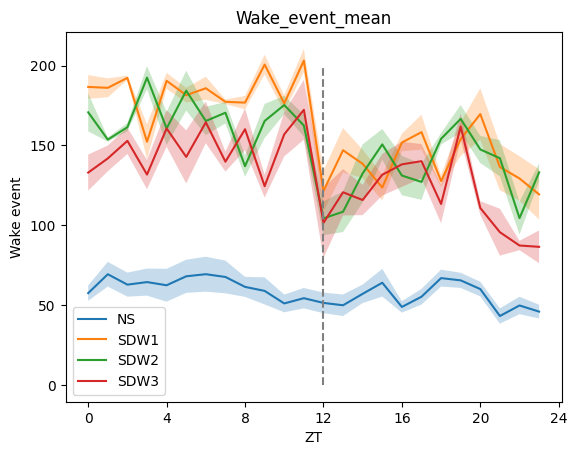

In [27]:
vari_plt = 'Wake_event_mean'

ax = plt.subplot()


plt.plot(NS_df['average_df'][f'Mean_{vari_plt}'], label = "NS")
plt.plot(SDW1_df['average_df'][f'Mean_{vari_plt}'], label = "SDW1")
plt.plot(SDW2_df['average_df'][f'Mean_{vari_plt}'], label = "SDW2")
plt.plot(SDW3_df['average_df'][f'Mean_{vari_plt}'], label = "SDW3")
plt.xlabel('ZT')
plt.ylabel('Wake event')
plt.xticks([0,4,8,12,16,20,24])
plt.vlines(x=12,ymin=0,ymax = 200, linestyles='dashed', color = "grey")
plt.title(vari_plt)

plt.fill_between(x = NS_df['average_df']['ZT'],
                y1 = NS_df['average_df'][f'Mean_{vari_plt}']-NS_df['sem_df'][f'SEM_{vari_plt}'],
                y2 = NS_df['average_df'][f'Mean_{vari_plt}']+NS_df['sem_df'][f'SEM_{vari_plt}'],
                alpha = 0.25
                    )
plt.fill_between(x = SDW1_df['average_df']['ZT'],
                y1 = SDW1_df['average_df'][f'Mean_{vari_plt}']-SDW1_df['sem_df'][f'SEM_{vari_plt}'],
                y2 = SDW1_df['average_df'][f'Mean_{vari_plt}']+SDW1_df['sem_df'][f'SEM_{vari_plt}'],
                alpha = 0.25
                    )
plt.fill_between(x = SDW2_df['average_df']['ZT'],
                y1 = SDW2_df['average_df'][f'Mean_{vari_plt}']-SDW2_df['sem_df'][f'SEM_{vari_plt}'],
                y2 = SDW2_df['average_df'][f'Mean_{vari_plt}']+SDW2_df['sem_df'][f'SEM_{vari_plt}'],
                alpha = 0.25
                    )
plt.fill_between(x = SDW3_df['average_df']['ZT'],
                y1 = SDW3_df['average_df'][f'Mean_{vari_plt}']-SDW3_df['sem_df'][f'SEM_{vari_plt}'],
                y2 = SDW3_df['average_df'][f'Mean_{vari_plt}']+SDW3_df['sem_df'][f'SEM_{vari_plt}'],
                alpha = 0.25
                    )
handles, labels = plt.gca().get_legend_handles_labels()
by_label = dict(zip(labels, handles))
plt.legend(by_label.values(), by_label.keys())

plt.savefig(fr'Gallery\\all-recording_{vari_plt}.svg', format = 'svg',transparent = True, dpi=300)

### Two graphs

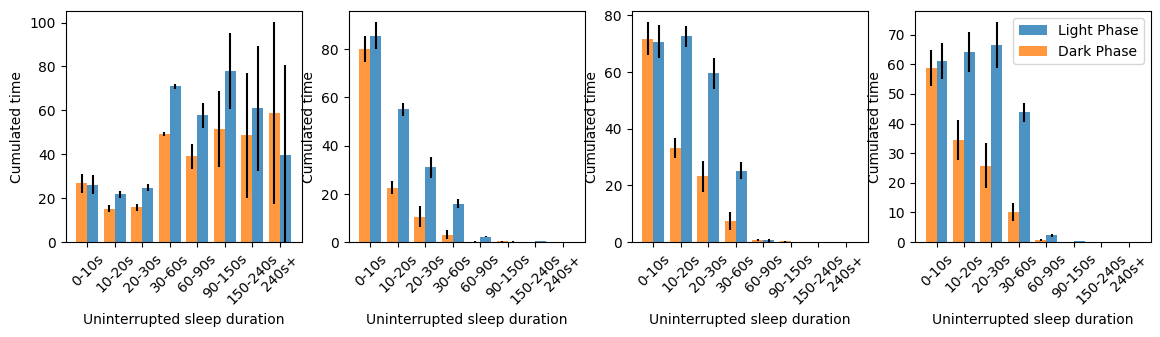

In [31]:
fig, ax = plt.subplots (1,4,figsize=(14,3), sharex=True, sharey=False)

ax[0].bar(x = NS_df['average_df']["ZT"], height = NS_df['average_df']['Mean_Light_phase_h'], yerr = NS_df['sem_df']['SEM_Dark_phase_h'],
           width = 0.4, align = 'edge', label = "Light Phase", alpha = 0.80)

ax[0].bar(x = NS_df['average_df']["ZT"], height = NS_df['average_df']['Mean_Dark_phase_h'], yerr = NS_df['sem_df']['SEM_Dark_phase_h'],
           width = -0.4, align = 'edge', label = "Dark Phase", alpha = 0.80)

ax[0].set_xticks(ticks = [0,1,2,3,4,5,6,7],labels=['0-10s',"10-20s","20-30s","30-60s","60-90s","90-150s","150-240s","240s+"],
                 rotation = 45)
ax[0].set_ylim(0)
ax[0].set_ylabel('Cumulated time')
ax[0].set_xlabel('Uninterrupted sleep duration')

ax[1].bar(x = SDW1_df['average_df']["ZT"], height = SDW1_df['average_df']['Mean_Light_phase_h'], yerr = SDW1_df['sem_df']['SEM_Dark_phase_h'],
           width = 0.4, align = 'edge', label = "Light Phase", alpha = 0.80)
ax[1].bar(x = SDW1_df['average_df']["ZT"], height = SDW1_df['average_df']['Mean_Dark_phase_h'], yerr = SDW1_df['sem_df']['SEM_Dark_phase_h'],
           width = -0.4, align = 'edge', label = "Dark Phase", alpha = 0.80)
ax[1].set_xticks(ticks = [0,1,2,3,4,5,6,7],labels=['0-10s',"10-20s","20-30s","30-60s","60-90s","90-150s","150-240s","240s+"],
                 rotation = 45)
ax[1].set_ylabel('Cumulated time')
ax[1].set_xlabel('Uninterrupted sleep duration')

ax[2].bar(x = SDW2_df['average_df']["ZT"], height = SDW2_df['average_df']['Mean_Light_phase_h'], yerr = SDW2_df['sem_df']['SEM_Dark_phase_h'],
           width = 0.4, align = 'edge', label = "Light Phase", alpha = 0.80)
ax[2].bar(x = SDW2_df['average_df']["ZT"], height = SDW2_df['average_df']['Mean_Dark_phase_h'], yerr = SDW2_df['sem_df']['SEM_Dark_phase_h'],
           width = -0.4, align = 'edge', label = "Dark Phase", alpha = 0.80)
ax[2].set_xticks(ticks = [0,1,2,3,4,5,6,7],labels=['0-10s',"10-20s","20-30s","30-60s","60-90s","90-150s","150-240s","240s+"],
                 rotation = 45)
ax[2].set_ylabel('Cumulated time')
ax[2].set_xlabel('Uninterrupted sleep duration')

ax[3].bar(x = SDW3_df['average_df']["ZT"], height = SDW3_df['average_df']['Mean_Light_phase_h'], yerr = SDW3_df['sem_df']['SEM_Dark_phase_h'],
           width = 0.4, align = 'edge', label = "Light Phase", alpha = 0.80)
ax[3].bar(x = SDW3_df['average_df']["ZT"], height = SDW3_df['average_df']['Mean_Dark_phase_h'], yerr = SDW3_df['sem_df']['SEM_Dark_phase_h'],
           width = -0.4, align = 'edge', label = "Dark Phase", alpha = 0.80)
ax[3].set_xticks(ticks = [0,1,2,3,4,5,6,7],labels=['0-10s',"10-20s","20-30s","30-60s","60-90s","90-150s","150-240s","240s+"],
                 rotation = 45)
ax[3].set_ylabel('Cumulated time')
ax[3].set_xlabel('Uninterrupted sleep duration')

ax[3].legend()
ax[2].set_ylim(0)

plt.savefig('Gallery\\bouts_duration_all.svg', format = 'svg', transparent = True, dpi= 300)

# Stat

In [30]:
import numpy as np 
import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import pandas as pd
import os
import matplotlib.pyplot as plt
import math
import matplotlib as mpl
from IPython.display import clear_output

## ZT + Condition Two Way ANOVA

In [31]:
dict_exp = {
    "NS" : "2025-06-16_Normal-Sleep",
    "SDW1" : "2025-06-27_Sleep-disruption_week1",
    "SDW2" : "2025-07-04_Sleep-disruption_week2",
    "SDW3" : "2025-07-11_Sleep-disruption_week3",
    # "SR" : "7-21-2025",
}

In [68]:
exp = dict_exp.keys()

sheet_to_open = "Other-ZT-Mean"

dir_input = r'E:\R\Sleep\output'
dfs = []
for ex in exp:
    print(ex)
    exp_folder_name = dict_exp[ex]
    directory_expe = f'{dir_input}\{exp_folder_name}'

    list_of_files = os.listdir(directory_expe)
    list_of_files = [files for files in list_of_files if files[0]!="~"]
    list_of_files

    

    for file in list_of_files:
        ID_mouse = file.split("_")[0]
        print(ID_mouse)
        df = pd.read_excel(f'{directory_expe}\{file}', sheet_name= sheet_to_open)
        ZT_list = df.iloc[:,0].astype(str)
        df['Condition'] = ex
        # df.iloc[:,0] = pd.Categorical(df.iloc[:,0])
        # df['subject'] = ID_mouse
        dfs.append(df)
    clear_output()

ddf = dfs[0]
for n in range(1, len(dfs)):
    ddf = pd.concat([ddf,dfs[n]])

ddf

,ZT,EMG_z_Mean,EMG_z_N,Delta_z_Mean,Delta_z_N,Theta_z_Mean,Theta_z_N,Alpha_z_Mean,Alpha_z_N,Sigma_z_Mean,Sigma_z_N,Beta_z_Mean,Beta_z_N,EEG_z_Mean,EEG_z_N,Temp_Mean,Temp_N,Condition
0,0,-0.134902,4,-0.028770,4,0.050906,4,0.043162,4,0.018216,4,-0.051639,4,-0.067843,4,36.521566,4,NS
1,1,-0.250062,4,-0.181347,4,0.126339,4,0.164198,4,0.146849,4,0.102225,4,-0.070522,4,35.458952,4,NS
2,2,-0.371932,4,-0.226454,4,0.215946,4,0.195718,4,0.120679,4,-0.016963,4,-0.070992,4,35.445786,4,NS
3,3,-0.263541,3,-0.166807,3,0.185143,3,0.184799,3,0.041970,3,-0.098771,3,-0.069229,3,35.427248,3,NS
4,4,-0.421576,3,-0.011597,3,0.002514,3,-0.001126,3,0.053766,3,0.022464,3,-0.076717,3,35.439265,3,NS
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19,19,-0.256628,2,0.049020,2,-0.000819,2,-0.123620,2,0.040747,2,0.009996,2,0.011604,2,36.819756,2,SDW3
20,20,-0.044915,2,-0.308910,2,0.425237,2,-0.145155,2,-0.140773,2,-0.173164,2,-0.032747,2,37.337526,2,SDW3
21,21,0.164089,2,-0.483196,2,0.506256,2,0.219450,2,-0.321304,2,-0.380932,2,-0.006547,2,37.605723,2,SDW3
22,22,0.118976,2,-0.298387,2,0.319060,2,0.257228,2,-0.339732,2,-0.396853,2,-0.070847,2,37.190235,2,SDW3


In [70]:
col_to_analyse = "Temp_Mean"
model = ols(f'{col_to_analyse} ~ C(Condition) + C(ZT) + C(Condition):C(ZT)', data=ddf).fit()
anova_result = sm.stats.anova_lm(model, type=2)
anova_result

,df,sum_sq,mean_sq,F,PR(>F)
C(Condition),3.0,33.912481,11.304160,34.198287,3.980772e-18
C(ZT),23.0,212.679166,9.246920,27.974553,2.702185e-52
C(Condition):C(ZT),69.0,12.455190,0.180510,0.546094,9.980558e-01
Residual,216.0,71.398272,0.330548,NaN,NaN


In [71]:
import scikit_posthocs as sp
print(col_to_analyse)
sp.posthoc_tukey(ddf, val_col=col_to_analyse, group_col='Condition',
                     # p_adjust='fdr_bh'
                     )


Temp_Mean


,NS,SDW1,SDW2,SDW3
NS,1.000000,0.000548,0.000061,0.000002
SDW1,0.000548,1.000000,0.960358,0.611628
SDW2,0.000061,0.960358,1.000000,0.884781
SDW3,0.000002,0.611628,0.884781,1.000000
